In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv("Building Energy Efficiency.csv")
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.7638,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.9800,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.9800,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.9800,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.9000,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness       768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Heating Load               768 non-null    float64
 9   Cooling Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 10


In [6]:
df.isnull().sum()

Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Heating Load                 0
Cooling Load                 0
dtype: int64

In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [9]:
X = df[
    [
        "Relative Compactness",
        "Surface Area",
        "Wall Area",
        "Roof Area",
        "Overall Height",
        "Orientation",
        "Glazing Area",
        "Glazing Area Distribution"
    ]
]
y = df["Heating Load"]

In [10]:
print("Features (X):")
print(X.columns.tolist())

print("\nTarget (Y):")
print(y.name)

Features (X):
['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution']

Target (Y):
Heating Load


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [12]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

In [13]:
start_time = time.perf_counter()

mlr.fit(X_train, y_train)

mlr_train_time = time.perf_counter() - start_time

print("MLR training time:", mlr_train_time, "seconds")

MLR training time: 0.25807589999999436 seconds


In [14]:
start_time = time.perf_counter()

y_pred_mlr = mlr.predict(X_test)

mlr_prediction_time = time.perf_counter() - start_time

print("MLR prediction time:", mlr_prediction_time, "seconds")

MLR prediction time: 0.005019699999934346 seconds


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mlr_r2 = r2_score(y_test, y_pred_mlr)
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print("MLR Performance")
print("----------------")
print("R²   :", mlr_r2)
print("MAE  :", mlr_mae)
print("RMSE :", mlr_rmse)

MLR Performance
----------------
R²   : 0.9092589250514285
MAE  : 2.2631046711133895
RMSE : 3.075399627424716


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.neighbors import KNeighborsRegressor

knnr = KNeighborsRegressor(n_neighbors=5)

In [19]:
start_time = time.perf_counter()

knnr.fit(X_train_scaled, y_train)

knnr_train_time = time.perf_counter() - start_time

print("KNNR training time:", knnr_train_time, "seconds")

KNNR training time: 0.00870190000000548 seconds


In [20]:
start_time = time.perf_counter()

y_pred_knnr = knnr.predict(X_test_scaled)

knnr_prediction_time = time.perf_counter() - start_time

print("KNNR prediction time:", knnr_prediction_time, "seconds")

KNNR prediction time: 0.005276799999933246 seconds


In [21]:
knnr_r2 = r2_score(y_test, y_pred_knnr)
knnr_mae = mean_absolute_error(y_test, y_pred_knnr)
knnr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knnr))

print("KNNR Performance")
print("----------------")
print("R²   :", knnr_r2)
print("MAE  :", knnr_mae)
print("RMSE :", knnr_rmse)

KNNR Performance
----------------
R²   : 0.9492447619814168
MAE  : 1.453909090909091
RMSE : 2.3000645897198444


In [22]:
comparison = pd.DataFrame({
    "Model": ["MLR", "KNNR"],
    "R²": [mlr_r2, knnr_r2],
    "RMSE": [mlr_rmse, knnr_rmse],
    "MAE": [mlr_mae, knnr_mae],
    "Training Time (s)": [mlr_train_time, knnr_train_time],
    "Prediction Time (s)": [mlr_prediction_time, knnr_prediction_time]
})

comparison

,Model,R²,RMSE,MAE,Training Time (s),Prediction Time (s)
0,MLR,0.909259,3.075400,2.263105,0.258076,0.005020
1,KNNR,0.949245,2.300065,1.453909,0.008702,0.005277


In [23]:
import psutil
import os

process = psutil.Process(os.getpid())

memory_before = process.memory_info().rss / (1024 ** 2)

# Run both models once
mlr.fit(X_train, y_train)
knnr.fit(X_train_scaled, y_train)

memory_after = process.memory_info().rss / (1024 ** 2)

print("Memory usage before models:", round(memory_before, 2), "MB")
print("Memory usage after models :", round(memory_after, 2), "MB")
print("Additional memory used    :", round(memory_after - memory_before, 2), "MB")

Memory usage before models: 252.04 MB
Memory usage after models : 252.1 MB
Additional memory used    : 0.06 MB


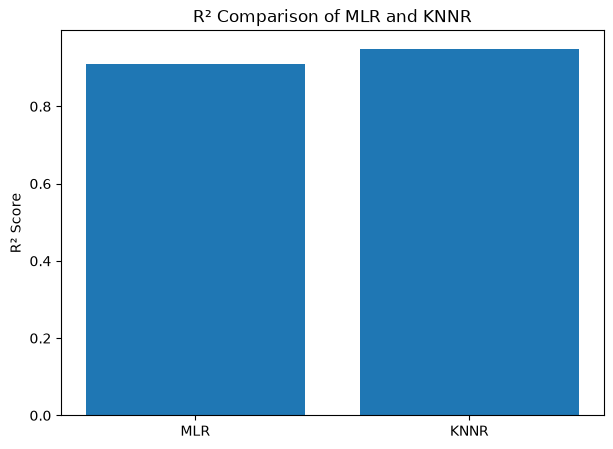

In [24]:
models = ["MLR", "KNNR"]

plt.figure(figsize=(7, 5))
plt.bar(models, [mlr_r2, knnr_r2])
plt.ylabel("R² Score")
plt.title("R² Comparison of MLR and KNNR")
plt.show()

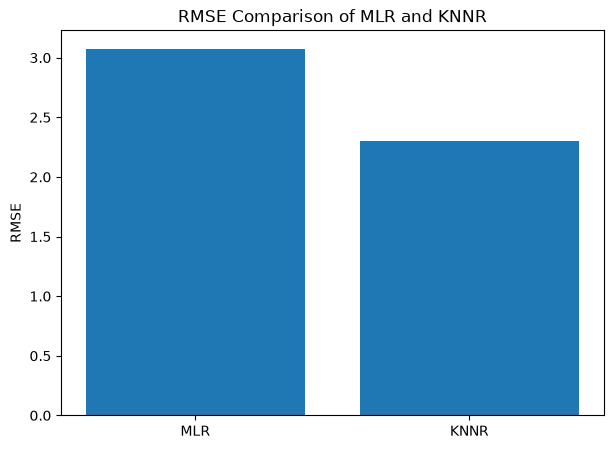

In [25]:
plt.figure(figsize=(7, 5))
plt.bar(models, [mlr_rmse, knnr_rmse])
plt.ylabel("RMSE")
plt.title("RMSE Comparison of MLR and KNNR")
plt.show()

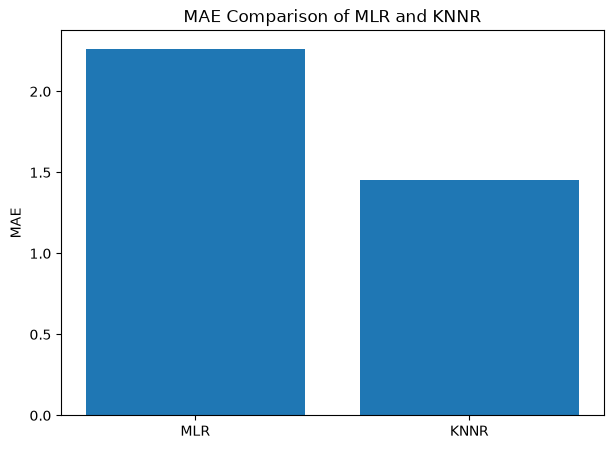

In [26]:
plt.figure(figsize=(7, 5))
plt.bar(models, [mlr_mae, knnr_mae])
plt.ylabel("MAE")
plt.title("MAE Comparison of MLR and KNNR")
plt.show()

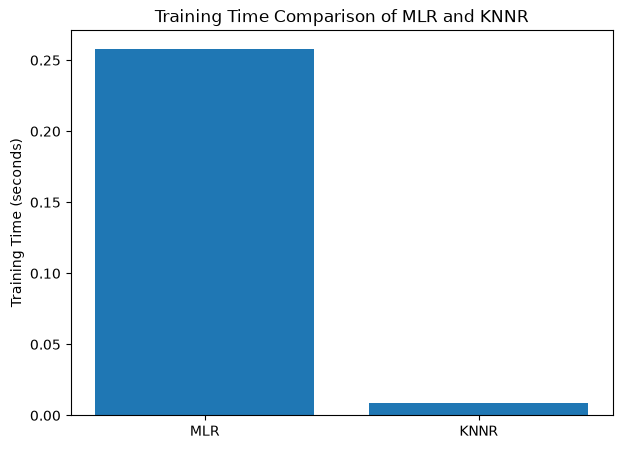

In [27]:
plt.figure(figsize=(7, 5))
plt.bar(
    models,
    [mlr_train_time, knnr_train_time]
)
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of MLR and KNNR")
plt.show()

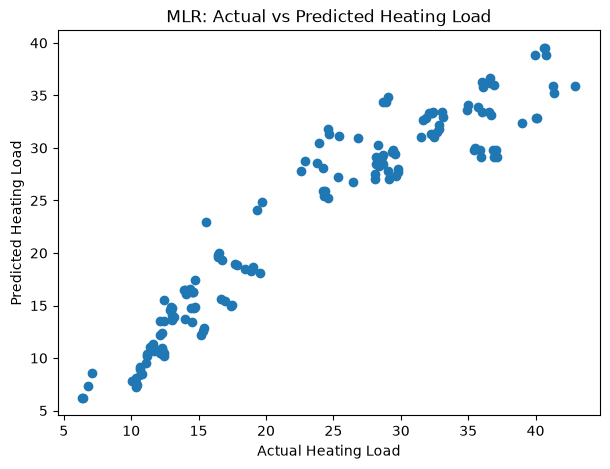

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("MLR: Actual vs Predicted Heating Load")
plt.show()

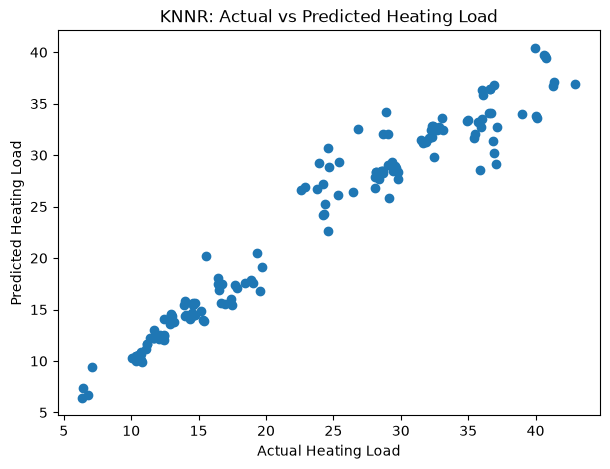

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_knnr)
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("KNNR: Actual vs Predicted Heating Load")
plt.show()

In [30]:
comparison.to_csv("MLR_KNNR_Comparison.csv", index=False)

print("Comparison table saved successfully.")

Comparison table saved successfully.


In [31]:
predictions = pd.DataFrame({
    "Actual Heating Load": y_test.values,
    "MLR Predicted": y_pred_mlr,
    "KNNR Predicted": y_pred_knnr
})

predictions.to_csv("MLR_KNNR_Predictions.csv", index=False)

print("Predictions saved successfully.")

Predictions saved successfully.


In [32]:
print("========================================")
print(" PERFORMANCE COMPARISON: MLR vs KNNR")
print("========================================")

print("\nMLR")
print("R²   :", round(mlr_r2, 4))
print("RMSE :", round(mlr_rmse, 4))
print("MAE  :", round(mlr_mae, 4))
print("Training Time :", round(mlr_train_time, 6), "seconds")
print("Prediction Time:", round(mlr_prediction_time, 6), "seconds")

print("\nKNNR")
print("R²   :", round(knnr_r2, 4))
print("RMSE :", round(knnr_rmse, 4))
print("MAE  :", round(knnr_mae, 4))
print("Training Time :", round(knnr_train_time, 6), "seconds")
print("Prediction Time:", round(knnr_prediction_time, 6), "seconds")

 PERFORMANCE COMPARISON: MLR vs KNNR

MLR
R²   : 0.9093
RMSE : 3.0754
MAE  : 2.2631
Training Time : 0.258076 seconds
Prediction Time: 0.00502 seconds

KNNR
R²   : 0.9492
RMSE : 2.3001
MAE  : 1.4539
Training Time : 0.008702 seconds
Prediction Time: 0.005277 seconds
